## Camera Level Analysis 
This notebook builds a camera-level dataset by combining:
- SSUSA observed species at each camera location
- IUCN predicted species from species range intersections
- comparison metrics such as missing species counts and Jaccard similarity


In [144]:
# Standard library
import os

# Data handling
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Spatial data
import geopandas as gpd

In [ ]:
# File paths and global settings
# ------------------------------------------------------------
base_ssusa_path = "../../data/ssusa"
SSUSA_CSV = "cleaned_snapshot_usa_iucn.csv"   # cleaned SSUSA observations table

OUTPUT_PATH = "../../outputs"
IUCN_DATA = "iucn_ranges_cleaned.geojson"     # cleaned IUCN range polygons
CAMERA_FOOTPRINTS = "ssusa_camera_footprints_1km.geojson"  # 1-km camera buffers

# Projected CRS used elsewhere when needed
AEA = "EPSG:5070"


# Helper function: build a consistent camera coordinate ID
# ------------------------------------------------------------
def make_coord_id(df, lon_col="Longitude", lat_col="Latitude", decimals=8):
    """
    Create a camera location key by rounding longitude and latitude
    to a fixed number of decimals and concatenating them.

    This helps match SSUSA records to camera footprint polygons
    even when coordinates differ slightly due to floating-point precision.
    """
    return (
        df[lon_col].round(decimals).astype(str) + "_"
        + df[lat_col].round(decimals).astype(str)
    )


In [146]:
# Load SSUSA observations and camera footprint polygons
# ------------------------------------------------------------
ssusa_file = os.path.join(base_ssusa_path, SSUSA_CSV)
camera_fp_file = os.path.join(OUTPUT_PATH, CAMERA_FOOTPRINTS)

ssusa = pd.read_csv(ssusa_file, low_memory=False)
camera_fp = gpd.read_file(camera_fp_file)

# Keep only rows with valid coordinates
ssusa = ssusa.dropna(subset=["Longitude", "Latitude"]).copy()

# Basic checks
print("SSUSA shape:", ssusa.shape)
print("Camera footprint shape:", camera_fp.shape)
print("Camera footprint CRS:", camera_fp.crs)

SSUSA shape: (698887, 26)
Camera footprint shape: (7303, 3)
Camera footprint CRS: EPSG:5070


### Identify right precision for Longitude / Latitude

In [147]:
# Compare raw vs rounded coordinates in footprint data
# This helps confirm whether rounding to 8 decimals is reasonable
# for building a stable camera identifier.
# ------------------------------------------------------------
fp = camera_fp.copy()

fp["coord_raw"] = (
    fp["Longitude"].astype(str) + "_" + fp["Latitude"].astype(str)
)

fp["coord_8"] = (
    fp["Longitude"].round(8).astype(str) + "_"
    + fp["Latitude"].round(8).astype(str)
)

print("Rows:", len(fp))
print("Unique raw coords:", fp["coord_raw"].nunique())
print("Unique rounded-8 coords:", fp["coord_8"].nunique())
print("Collapsed by rounding:", fp["coord_raw"].nunique() - fp["coord_8"].nunique())

Rows: 7303
Unique raw coords: 7303
Unique rounded-8 coords: 7303
Collapsed by rounding: 0


### Create Camera Coordinate IDs
Create a consistent camera identifier from rounded longitude and latitude.

In [148]:
# Create camera coordinate ID in SSUSA observations
# ------------------------------------------------------------
ssusa_cam = ssusa.dropna(subset=["Longitude", "Latitude"]).copy()

ssusa_cam["coord_id"] = make_coord_id(
    ssusa_cam,
    decimals=8
)

### Diagnostic Checks on Camera Locations
Check whether the same camera location is associated with multiple habitats or multiple years.

In [149]:
# Check how many unique habitats appear for each camera location
# within a single year
# ------------------------------------------------------------
habitat_per_loc_year = (
    ssusa_cam
    .groupby(["Year", "coord_id"])["Habitat"]
    .nunique()
    .reset_index(name="n_habitats")
)

print("Unique camera-year combinations:", habitat_per_loc_year.shape[0])
print("Max habitats per camera-year:", habitat_per_loc_year["n_habitats"].max())

# Check how many unique habitats appear for each camera location
# across all years
# ------------------------------------------------------------
habitat_per_location = (
    ssusa_cam
    .groupby("coord_id")["Habitat"]
    .nunique()
    .reset_index(name="n_habitats")
)

print("Unique camera locations:", habitat_per_location.shape[0])
print("Max habitats per location:", habitat_per_location["n_habitats"].max())   

Unique camera-year combinations: 8661
Max habitats per camera-year: 1
Unique camera locations: 7303
Max habitats per location: 2


In [96]:
## SSUSA find what is the maximum number of cameras for camera - year combination 
habitat_per_location = (
    ssusa_cam
    .groupby("coord_id")["Habitat"]
    .nunique()
    .reset_index(name="n_habitats")
)

habitat_per_location.head()

max_row = habitat_per_location.loc[
    habitat_per_location["n_habitats"].idxmax()
]

print(max_row)

max_habitats = habitat_per_location["n_habitats"].max()
print("Maximum number of habitats for any camera location:", max_habitats)

coord_id      -104.84615_38.9845
n_habitats                     2
Name: 181, dtype: object
Maximum number of habitats for any camera location: 2


###  Build Camera-Level Metadata Table
Create a deployment-level summary to compute survey effort correctly, then build one metadata row per camera.

In [150]:
# how many unique camera locations are present?
# ------------------------------------------------------------
print("Unique cameras (coord_id):", ssusa_cam["coord_id"].nunique())

#print("\nSample rows:")
# ssusa_cam[["Longitude", "Latitude", "coord_id"]].head()

Unique cameras (coord_id): 7303


In [151]:
# Build a deployment-level table
# Each row represents one unique deployment at one camera.
# This is needed because the raw SSUSA table is at the
# observation level, so Survey_Nights may repeat across many
# species records within the same deployment.
# ------------------------------------------------------------
deployment_summary = (
    ssusa_cam[
        [
            "coord_id",
            "Deployment_ID",
            "Year",
            "Project",
            "Start_Date",
            "End_Date",
            "Survey_Nights"
        ]
    ]
    .drop_duplicates()
    .copy()
)

print("Deployment-level rows:", deployment_summary.shape[0])
deployment_summary.head()




Deployment-level rows: 9298


,coord_id,Deployment_ID,Year,Project,Start_Date,End_Date,Survey_Nights
0,-136.2225_59.42643,AK_Forest_Chilkat_Preserve_1,2019,Snapshot USA 2019,2019-08-31,2019-11-03,64.0
99,-135.9288_59.39905,AK_Forest_Chilkat_Preserve_2,2019,Snapshot USA 2019,2019-08-29,2019-11-04,67.0
110,-135.84097_59.3802,AK_Forest_Chilkat_Preserve_3,2019,Snapshot USA 2019,2019-08-29,2019-11-03,66.0
120,-136.30461_59.42641,AK_Forest_Chilkat_Preserve_4,2019,Snapshot USA 2019,2019-08-27,2019-11-03,68.0
121,-136.15141_59.41195,AK_Forest_Chilkat_Preserve_5,2019,Snapshot USA 2019,2019-08-27,2019-11-03,68.0


In [152]:
# Compute total survey effort per camera
# Sum Survey_Nights across unique deployments so effort is not
# double-counted across repeated observation rows.
# ------------------------------------------------------------
unique_nights = (
    deployment_summary
    .groupby("coord_id")["Survey_Nights"]
    .sum()
    .reset_index(name="unique_nights")
)

print("Camera-level effort rows:", unique_nights.shape[0])
unique_nights.head()

Camera-level effort rows: 7303


,coord_id,unique_nights
0,-100.23311_35.92725,18.0
1,-100.24179_35.92768,20.0
2,-100.241802_35.927679,49.0
3,-100.24181_35.92775,36.0
4,-100.2421271_35.927561,4.0


In [153]:

# Check whether any camera location is linked to more than one
# camera trap array
# ------------------------------------------------------------
array_check = (
    ssusa_cam
    .groupby("coord_id")["Camera_Trap_Array"]
    .nunique()
    .reset_index(name="n_arrays")
)

array_check["n_arrays"].value_counts().sort_index()


n_arrays
1    7300
2       3
Name: count, dtype: int64

In [154]:
# ------------------------------------------------------------
# Inspect camera locations associated with multiple arrays
# ------------------------------------------------------------
multi_array_cameras = (
    array_check.loc[array_check["n_arrays"] > 1, "coord_id"]
)

multi_array_cameras

2081    -71.7209_41.55074
2938           -75.9_35.8
2939           -75.9_35.9
Name: coord_id, dtype: object

In [156]:
# ------------------------------------------------------------
# Helper function: return the most frequent non-missing value
# in a grouped series
# ------------------------------------------------------------
def most_common(x):
    x = x.dropna()
    return x.mode().iloc[0] if not x.empty else np.nan


# ------------------------------------------------------------
# Helper function: return unique non-missing values as a set
# ------------------------------------------------------------
def to_set(x):
    return set(x.dropna())

In [157]:
# Build one metadata row per camera location
# - For Habitat, Development_Level, and Feature_Type,
#   assign the most common value across SSUSA records for that camera
# - Keep one longitude/latitude pair per camera
# ------------------------------------------------------------
meta_other = (
    ssusa_cam
    .groupby("coord_id")
    .agg({
        "Habitat": most_common,
        "Development_Level": most_common,
        "Feature_Type": most_common,
        "Camera_Trap_Array": to_set,
        "Longitude": "first",
        "Latitude": "first"
    })
    .reset_index()
)

# ------------------------------------------------------------
# Merge camera metadata with survey effort
# ------------------------------------------------------------
camera_meta = meta_other.merge(
    unique_nights,
    on="coord_id",
    how="left"
)

print("Camera metadata rows:", camera_meta.shape[0])
camera_meta.head()

Camera metadata rows: 7303


,coord_id,Habitat,Development_Level,Feature_Type,Camera_Trap_Array,Longitude,Latitude,unique_nights
0,-100.23311_35.92725,grassland,wild,water source,{GeneHowe},-100.233110,35.927250,18.0
1,-100.24179_35.92768,grassland,wild,water source,{GeneHowe},-100.241790,35.927680,20.0
2,-100.241802_35.927679,grassland,wild,water source,{GeneHowe},-100.241802,35.927679,49.0
3,-100.24181_35.92775,grassland,wild,water source,{GeneHowe},-100.241810,35.927750,36.0
4,-100.2421271_35.927561,grassland,wild,trail game,{GeneHowe},-100.242127,35.927561,4.0


### Build Observed Species Lists per Camera
Aggregate SSUSA observations to the camera level by collecting the set of species observed at each camera.

In [158]:
# Build observed species sets per camera
# For each camera location, collect the unique scientific names
# recorded in SSUSA observations.
# ------------------------------------------------------------
observed_by_camera = (
    ssusa_cam
    .groupby("coord_id")["Sci_Name"]
    .apply(lambda x: set(x.dropna()))
    .reset_index(name="obs_species")
)

# Count observed species richness at each camera
observed_by_camera["S_obs"] = observed_by_camera["obs_species"].apply(len)

print("Observed-species rows:", observed_by_camera.shape[0])
observed_by_camera.head()

Observed-species rows: 7303


,coord_id,obs_species,S_obs
0,-100.23311_35.92725,"{procyon lotor, odocoileus virginianus}",2
1,-100.24179_35.92768,"{odocoileus virginianus, procyon lotor}",2
2,-100.241802_35.927679,"{canis latrans, odocoileus hemionus, odocoileu...",4
3,-100.24181_35.92775,{odocoileus virginianus},1
4,-100.2421271_35.927561,{odocoileus virginianus},1


In [159]:
# Merge camera metadata with observed species summaries
# This creates the base camera-level table before adding IUCN
# predicted species.
# ------------------------------------------------------------
camera_table = camera_meta.merge(
    observed_by_camera,
    on="coord_id",
    how="left"
)

# Replace missing observed-species entries with empty sets
camera_table["obs_species"] = camera_table["obs_species"].apply(
    lambda x: x if isinstance(x, set) else set()
)

# Recompute observed richness after filling missing values
camera_table["S_obs"] = camera_table["obs_species"].apply(len)

print("Camera table rows:", camera_table.shape[0])
camera_table.head()

Camera table rows: 7303


,coord_id,Habitat,Development_Level,Feature_Type,Camera_Trap_Array,Longitude,Latitude,unique_nights,obs_species,S_obs
0,-100.23311_35.92725,grassland,wild,water source,{GeneHowe},-100.233110,35.927250,18.0,"{procyon lotor, odocoileus virginianus}",2
1,-100.24179_35.92768,grassland,wild,water source,{GeneHowe},-100.241790,35.927680,20.0,"{odocoileus virginianus, procyon lotor}",2
2,-100.241802_35.927679,grassland,wild,water source,{GeneHowe},-100.241802,35.927679,49.0,"{canis latrans, odocoileus hemionus, odocoileu...",4
3,-100.24181_35.92775,grassland,wild,water source,{GeneHowe},-100.241810,35.927750,36.0,{odocoileus virginianus},1
4,-100.2421271_35.927561,grassland,wild,trail game,{GeneHowe},-100.242127,35.927561,4.0,{odocoileus virginianus},1


### Prepare Camera Footprints for Spatial Matching
Create the same camera coordinate ID in the footprint layer so footprint polygons can be matched back to SSUSA camera records.

In [160]:
# Inspect camera footprint data
# These polygons represent the 1-km camera buffers used for
# spatial intersection with IUCN range maps.
# ------------------------------------------------------------
print("Camera footprint rows:", camera_fp.shape[0])
print("Camera footprint CRS:", camera_fp.crs)
camera_fp.head()

Camera footprint rows: 7303
Camera footprint CRS: EPSG:5070


,Longitude,Latitude,geometry
0,-136.22250,59.42643,"POLYGON ((-2435854.994 4519384.214, -2435859.8..."
1,-135.92880,59.39905,"POLYGON ((-2420256.573 4509346.493, -2420261.3..."
2,-135.84097,59.38020,"POLYGON ((-2416024.27 4505366.361, -2416029.08..."
3,-136.30461,59.42641,"POLYGON ((-2440528.846 4521489.864, -2440533.6..."
4,-136.15141,59.41195,"POLYGON ((-2432409.109 4516225.035, -2432413.9..."


In [161]:
# Create camera coordinate IDs in the footprint layer
# This should match the coord_id built from SSUSA camera records.
# ------------------------------------------------------------
camera_fp["coord_id"] = make_coord_id(
    camera_fp,
    lon_col="Longitude",
    lat_col="Latitude",
    decimals=8
)

camera_fp[["Longitude", "Latitude", "coord_id"]].head()


,Longitude,Latitude,coord_id
0,-136.22250,59.42643,-136.2225_59.42643
1,-135.92880,59.39905,-135.9288_59.39905
2,-135.84097,59.38020,-135.84097_59.3802
3,-136.30461,59.42641,-136.30461_59.42641
4,-136.15141,59.41195,-136.15141_59.41195


In [162]:
# Compare camera IDs between SSUSA records and footprint polygons
# This is a diagnostic check to confirm matching coverage.
# ------------------------------------------------------------
ssusa_ids = set(ssusa_cam["coord_id"].dropna().unique())
footprint_ids = set(camera_fp["coord_id"].dropna().unique())

print("Unique coord_id in SSUSA:", len(ssusa_ids))
print("Unique coord_id in footprints:", len(footprint_ids))
print("IDs in SSUSA but not footprints:", len(ssusa_ids - footprint_ids))
print("IDs in footprints but not SSUSA:", len(footprint_ids - ssusa_ids))

Unique coord_id in SSUSA: 7303
Unique coord_id in footprints: 7303
IDs in SSUSA but not footprints: 0
IDs in footprints but not SSUSA: 0


### Intersect IUCN Ranges with Camera Footprints
Use spatial overlap between IUCN range polygons and camera footprint polygons to determine which species are predicted at each camera.

In [163]:
# Load cleaned IUCN range polygons
# ------------------------------------------------------------
iucn_file = os.path.join(OUTPUT_PATH, IUCN_DATA)
iucn = gpd.read_file(iucn_file)

print("IUCN rows:", iucn.shape[0])
print("IUCN CRS:", iucn.crs)
iucn.head()

IUCN rows: 130
IUCN CRS: EPSG:5070


,id_no,sci_name,presence,origin,seasonal,compiler,yrcompiled,citation,subspecies,subpop,...,order_,family,genus,category,marine,terrestria,freshwater,SHAPE_Leng,SHAPE_Area,geometry
0,11509,leopardus pardalis,1,1,1,"Arturo Caso, Paula Cruz, Carlos De Angelo, Yam...",2015,"Arturo Caso, Paula Cruz, Carlos De Angelo, Yam...",None,None,...,CARNIVORA,FELIDAE,Leopardus,LC,false,true,false,601.010774,1212.792471,"MULTIPOLYGON (((-1391965.19 1029682.861, -1391..."
1,41777,pecari tajacu,1,1,1,IUCN,2008,IUCN (International Union for Conservation of ...,None,None,...,ARTIODACTYLA,TAYASSUIDAE,Pecari,LC,false,true,false,504.481816,1292.732191,"MULTIPOLYGON (((-1432538.009 1435374.825, -143..."
2,6290,dasypus novemcinctus,1,1,1,IUCN,2014,IUCN (International Union for Conservation of ...,None,None,...,CINGULATA,DASYPODIDAE,Dasypus,LC,false,true,false,589.422226,1560.551096,"MULTIPOLYGON (((1587947.786 371290.008, 158820..."
3,18868,puma concolor,1,1,1,IUCN,2015,IUCN (International Union for Conservation of ...,None,None,...,CARNIVORA,FELIDAE,Puma,LC,false,true,false,1076.870803,1923.350267,"MULTIPOLYGON (((-2060713.678 1466026.091, -206..."
4,88151055,lasiurus blossevillii,1,1,1,IUCN,2016,IUCN (International Union for Conservation of ...,None,None,...,CHIROPTERA,VESPERTILIONIDAE,Lasiurus,LC,false,true,false,668.890721,1608.364725,"MULTIPOLYGON (((-2310309.746 1995609.351, -231..."


In [164]:
# Keep IUCN rows with valid species names and geometry
# ------------------------------------------------------------
iucn = iucn.dropna(subset=["sci_name", "geometry"]).copy()
iucn = iucn.loc[iucn.geometry.is_valid].copy()

print("Valid IUCN rows:", iucn.shape[0])


Valid IUCN rows: 130


In [165]:
# Reproject IUCN ranges if needed so they match the camera
# footprint CRS before spatial overlay
# ------------------------------------------------------------
if iucn.crs != camera_fp.crs:
    iucn = iucn.to_crs(camera_fp.crs)

print("IUCN CRS after check:", iucn.crs)
print("Footprint CRS:", camera_fp.crs)

IUCN CRS after check: EPSG:5070
Footprint CRS: EPSG:5070


In [166]:
# Keep only the columns needed for spatial intersection
# ------------------------------------------------------------
iucn_small = iucn[["sci_name", "geometry"]].copy()
camera_fp_small = camera_fp[["coord_id", "geometry"]].copy()

In [169]:
# Intersect camera footprints with IUCN range polygons
# Each output row represents one camera footprint overlapping
# one species range polygon.
# ------------------------------------------------------------
camera_iucn = gpd.overlay(
    camera_fp_small,
    iucn_small,
    how="intersection"
)

print("Intersection rows:", camera_iucn.shape[0])
camera_iucn.head(50)

/Users/neelima/miniconda3/lib/python3.12/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


Intersection rows: 133292


,coord_id,sci_name,geometry
0,-136.2225_59.42643,canis latrans,"POLYGON ((-2435859.809 4519286.197, -2435874.2..."
1,-136.2225_59.42643,odocoileus hemionus,"POLYGON ((-2435859.809 4519286.197, -2435874.2..."
2,-136.2225_59.42643,ursus americanus,"POLYGON ((-2435859.809 4519286.197, -2435874.2..."
3,-136.2225_59.42643,sorex monticola,"POLYGON ((-2435859.809 4519286.197, -2435874.2..."
4,-136.2225_59.42643,oreamnos americanus,"POLYGON ((-2435859.809 4519286.197, -2435874.2..."
5,-136.2225_59.42643,erethizon dorsatum,"POLYGON ((-2435859.809 4519286.197, -2435874.2..."
6,-136.2225_59.42643,martes americana,"POLYGON ((-2435859.809 4519286.197, -2435874.2..."
7,-136.2225_59.42643,lepus americanus,"POLYGON ((-2435859.809 4519286.197, -2435874.2..."
8,-136.2225_59.42643,ursus arctos,"POLYGON ((-2435859.809 4519286.197, -2435874.2..."
9,-136.2225_59.42643,marmota caligata,"POLYGON ((-2435859.809 4519286.197, -2435874.2..."


In [170]:
# Build predicted species sets per camera from the spatial
# intersection results
# ------------------------------------------------------------
predicted_by_camera = (
    camera_iucn
    .groupby("coord_id")["sci_name"]
    .apply(lambda x: set(x.dropna()))
    .reset_index(name="pred_species")
)

# Count predicted species richness at each camera
predicted_by_camera["S_pred"] = predicted_by_camera["pred_species"].apply(len)

print("Predicted-species rows:", predicted_by_camera.shape[0])
predicted_by_camera.head(50)

Predicted-species rows: 7221


,coord_id,pred_species,S_pred
0,-100.23311_35.92725,"{mustela nigripes, dasypus novemcinctus, lepus...",22
1,-100.24179_35.92768,"{mustela nigripes, dasypus novemcinctus, lepus...",22
2,-100.241802_35.927679,"{mustela nigripes, dasypus novemcinctus, lepus...",22
3,-100.24181_35.92775,"{mustela nigripes, dasypus novemcinctus, lepus...",22
4,-100.2421271_35.927561,"{mustela nigripes, dasypus novemcinctus, lepus...",22
5,-100.2454722_35.933346,"{mustela nigripes, dasypus novemcinctus, lepus...",22
6,-100.246747_35.932371,"{mustela nigripes, dasypus novemcinctus, lepus...",22
7,-100.248028_47.41722,"{urocitellus richardsonii, clethrionomys gappe...",21
8,-100.252871_47.426957,"{urocitellus richardsonii, clethrionomys gappe...",21
9,-100.256847_35.896232,"{mustela nigripes, dasypus novemcinctus, lepus...",22


## Merge Observed and Predicted Species and Compute Comparison Metrics
Combine SSUSA observed species and IUCN predicted species at the camera level, then calculate overlap, missing species, and Jaccard similarity.

In [171]:
# Merge predicted species into the camera-level table
# ------------------------------------------------------------
camera_compare = camera_table.merge(
    predicted_by_camera,
    on="coord_id",
    how="left"
)

# Replace missing predicted-species entries with empty sets
camera_compare["pred_species"] = camera_compare["pred_species"].apply(
    lambda x: x if isinstance(x, set) else set()
)

# Recompute predicted richness after filling missing values
camera_compare["S_pred"] = camera_compare["pred_species"].apply(len)

print("Camera comparison rows:", camera_compare.shape[0])
camera_compare.head()

Camera comparison rows: 7303


,coord_id,Habitat,Development_Level,Feature_Type,Camera_Trap_Array,Longitude,Latitude,unique_nights,obs_species,S_obs,pred_species,S_pred
0,-100.23311_35.92725,grassland,wild,water source,{GeneHowe},-100.233110,35.927250,18.0,"{procyon lotor, odocoileus virginianus}",2,"{mustela nigripes, dasypus novemcinctus, lepus...",22
1,-100.24179_35.92768,grassland,wild,water source,{GeneHowe},-100.241790,35.927680,20.0,"{odocoileus virginianus, procyon lotor}",2,"{mustela nigripes, dasypus novemcinctus, lepus...",22
2,-100.241802_35.927679,grassland,wild,water source,{GeneHowe},-100.241802,35.927679,49.0,"{canis latrans, odocoileus hemionus, odocoileu...",4,"{mustela nigripes, dasypus novemcinctus, lepus...",22
3,-100.24181_35.92775,grassland,wild,water source,{GeneHowe},-100.241810,35.927750,36.0,{odocoileus virginianus},1,"{mustela nigripes, dasypus novemcinctus, lepus...",22
4,-100.2421271_35.927561,grassland,wild,trail game,{GeneHowe},-100.242127,35.927561,4.0,{odocoileus virginianus},1,"{mustela nigripes, dasypus novemcinctus, lepus...",22


In [172]:
# Compute species-set comparisons for each camera
# - overlap_species: species both observed and predicted
# - missing_species: predicted by IUCN but not observed in SSUSA
# - additional_species: observed in SSUSA but not predicted by IUCN
# - union_species: all species appearing in either source
# ------------------------------------------------------------
camera_compare["overlap_species"] = camera_compare.apply(
    lambda row: row["obs_species"] & row["pred_species"],
    axis=1
)

camera_compare["missing_species"] = camera_compare.apply(
    lambda row: row["pred_species"] - row["obs_species"],
    axis=1
)

camera_compare["additional_species"] = camera_compare.apply(
    lambda row: row["obs_species"] - row["pred_species"],
    axis=1
)

camera_compare["union_species"] = camera_compare.apply(
    lambda row: row["obs_species"] | row["pred_species"],
    axis=1
)


In [173]:
# Count the number of species in each comparison set
# ------------------------------------------------------------
camera_compare["overlap_n"] = camera_compare["overlap_species"].apply(len)
camera_compare["missing_n"] = camera_compare["missing_species"].apply(len)
camera_compare["additional_n"] = camera_compare["additional_species"].apply(len)
camera_compare["union_n"] = camera_compare["union_species"].apply(len)

camera_compare[
    ["coord_id", "S_obs", "S_pred", "overlap_n", "missing_n", "additional_n", "union_n"]
].head()

,coord_id,S_obs,S_pred,overlap_n,missing_n,additional_n,union_n
0,-100.23311_35.92725,2,22,2,20,0,22
1,-100.24179_35.92768,2,22,2,20,0,22
2,-100.241802_35.927679,4,22,4,18,0,22
3,-100.24181_35.92775,1,22,1,21,0,22
4,-100.2421271_35.927561,1,22,1,21,0,22


In [174]:
# Compute Jaccard similarity
# Jaccard = overlap / union
# If both observed and predicted sets are empty, return NaN
# ------------------------------------------------------------
camera_compare["jaccard_index"] = camera_compare.apply(
    lambda row: (
        row["overlap_n"] / row["union_n"]
        if row["union_n"] > 0 else np.nan
    ),
    axis=1
)

camera_compare[["coord_id", "jaccard_index"]].head()

,coord_id,jaccard_index
0,-100.23311_35.92725,0.090909
1,-100.24179_35.92768,0.090909
2,-100.241802_35.927679,0.181818
3,-100.24181_35.92775,0.045455
4,-100.2421271_35.927561,0.045455


##  Summary Statistics and Output
Inspect the final camera-level comparison table and save it for downstream analysis.

In [175]:
# Summarize key camera-level comparison metrics
# ------------------------------------------------------------
print("Number of cameras:", camera_compare.shape[0])
print("\nJaccard summary:")
print(camera_compare["jaccard_index"].describe())

print("\nCameras with no predicted species:", (camera_compare["S_pred"] == 0).sum())
print("Cameras with no observed species:", (camera_compare["S_obs"] == 0).sum())
print("Cameras with overlap > 0:", (camera_compare["overlap_n"] > 0).sum())

Number of cameras: 7303

Jaccard summary:
count    7303.000000
mean        0.206075
std         0.127994
min         0.000000
25%         0.105263
50%         0.187500
75%         0.285714
max         0.785714
Name: jaccard_index, dtype: float64

Cameras with no predicted species: 82
Cameras with no observed species: 0
Cameras with overlap > 0: 7111


In [176]:
# Save final camera-level comparison table for later analysis
# ------------------------------------------------------------
out_file = os.path.join(
    OUTPUT_PATH,
    "camera_level_ssusa_iucn_comparison.pkl"
)

camera_compare.to_pickle(out_file)

print("Saved:", out_file)


Saved: ../../outputs/camera_level_ssusa_iucn_comparison.pkl


In [31]:
# add counts to the table 
# ------------------------------------------------------------
camera_compare["missing_n"] = camera_compare["missing_species"].apply(len)
camera_compare["additional_n"] = camera_compare["additional_species"].apply(len)
camera_compare["overlap_n"] = camera_compare["overlap_species"].apply(len)
camera_compare["union_n"] = camera_compare["union_species"].apply(len)

In [32]:
# Jaccard index = intersection / union
# If union is 0, return NA
# ------------------------------------------------------------
camera_compare["jaccard_index"] = camera_compare.apply(
    lambda row: row["overlap_n"] / row["union_n"]
    if row["union_n"] > 0 else pd.NA,
    axis=1
)

In [33]:
print("Rows in camera_compare:", len(camera_compare))
print(camera_compare.columns)
print("\nSample columns:")
camera_compare[
        [
            "coord_id",
            "S_obs",
            "S_pred",
            "missing_n",
            "additional_n",
            "overlap_n",
            "union_n",
            "jaccard_index"
        ]
    ].head()


Rows in camera_compare: 7303
Index(['coord_id', 'Habitat', 'Development_Level', 'Feature_Type',
       'Camera_Trap_Array', 'Longitude', 'Latitude', 'unique_nights',
       'obs_species', 'S_obs', 'pred_species', 'S_pred', 'missing_species',
       'additional_species', 'overlap_species', 'union_species', 'missing_n',
       'additional_n', 'overlap_n', 'union_n', 'jaccard_index'],
      dtype='object')

Sample columns:


,coord_id,S_obs,S_pred,missing_n,additional_n,overlap_n,union_n,jaccard_index
0,-100.23311_35.92725,2,23,21,0,2,23,0.086957
1,-100.24179_35.92768,2,23,21,0,2,23,0.086957
2,-100.241802_35.927679,4,23,19,0,4,23,0.173913
3,-100.24181_35.92775,1,23,22,0,1,23,0.043478
4,-100.2421271_35.927561,1,23,22,0,1,23,0.043478


In [34]:
# Results analysis 
print(camera_compare["jaccard_index"].describe())

print("\nCameras with no predicted species:", (camera_compare["S_pred"] == 0).sum())
print("Cameras with no observed species:", (camera_compare["S_obs"] == 0).sum())
print("Cameras with some overlap:", (camera_compare["overlap_n"] > 0).sum())

count    7303.000000
mean        0.207676
std         0.128324
min         0.000000
25%         0.105263
50%         0.190476
75%         0.294118
max         0.785714
Name: jaccard_index, dtype: float64

Cameras with no predicted species: 82
Cameras with no observed species: 0
Cameras with some overlap: 7126


In [35]:
camera_compare.to_pickle(
    os.path.join(OUTPUT_PATH, "camera_level_ssusa_iucn_comparison.pkl")
)

### Visualizations
Explore how camera-level agreement between SSUSA and IUCN varies across habitat categories and survey effort.

In [177]:
# Reload final camera-level comparison table if needed
# ------------------------------------------------------------
camera_compare = pd.read_pickle(
    os.path.join(OUTPUT_PATH, "camera_level_ssusa_iucn_comparison.pkl")
)

print(camera_compare.shape)
camera_compare.head()

(7303, 21)


,coord_id,Habitat,Development_Level,Feature_Type,Camera_Trap_Array,Longitude,Latitude,unique_nights,obs_species,S_obs,...,S_pred,overlap_species,missing_species,additional_species,union_species,overlap_n,missing_n,additional_n,union_n,jaccard_index
0,-100.23311_35.92725,grassland,wild,water source,{GeneHowe},-100.233110,35.927250,18.0,"{procyon lotor, odocoileus virginianus}",2,...,22,"{procyon lotor, odocoileus virginianus}","{mustela nigripes, dasypus novemcinctus, lepus...",{},"{mustela nigripes, dasypus novemcinctus, lepus...",2,20,0,22,0.090909
1,-100.24179_35.92768,grassland,wild,water source,{GeneHowe},-100.241790,35.927680,20.0,"{odocoileus virginianus, procyon lotor}",2,...,22,"{odocoileus virginianus, procyon lotor}","{mustela nigripes, dasypus novemcinctus, lepus...",{},"{mustela nigripes, dasypus novemcinctus, lepus...",2,20,0,22,0.090909
2,-100.241802_35.927679,grassland,wild,water source,{GeneHowe},-100.241802,35.927679,49.0,"{canis latrans, odocoileus hemionus, odocoileu...",4,...,22,"{canis latrans, odocoileus hemionus, odocoileu...","{mustela nigripes, taxidea taxus, didelphis vi...",{},"{mustela nigripes, dasypus novemcinctus, lepus...",4,18,0,22,0.181818
3,-100.24181_35.92775,grassland,wild,water source,{GeneHowe},-100.241810,35.927750,36.0,{odocoileus virginianus},1,...,22,{odocoileus virginianus},"{mustela nigripes, dasypus novemcinctus, lepus...",{},"{mustela nigripes, dasypus novemcinctus, lepus...",1,21,0,22,0.045455
4,-100.2421271_35.927561,grassland,wild,trail game,{GeneHowe},-100.242127,35.927561,4.0,{odocoileus virginianus},1,...,22,{odocoileus virginianus},"{mustela nigripes, dasypus novemcinctus, lepus...",{},"{mustela nigripes, dasypus novemcinctus, lepus...",1,21,0,22,0.045455


In [182]:
# Prepare plotting data
# Habitat, Development_Level, and Feature_Type are already
# reduced to one representative value per camera, so no
# exploding is needed.
# ------------------------------------------------------------
plot_df = camera_compare.copy()

print(plot_df.shape)
plot_df[[
    "coord_id",
    "Habitat",
    "Development_Level",
    "Feature_Type",
    "unique_nights",
    "jaccard_index",
    "missing_n"
]].head()

(7303, 21)


,coord_id,Habitat,Development_Level,Feature_Type,unique_nights,jaccard_index,missing_n
0,-100.23311_35.92725,grassland,wild,water source,18.0,0.090909,20
1,-100.24179_35.92768,grassland,wild,water source,20.0,0.090909,20
2,-100.241802_35.927679,grassland,wild,water source,49.0,0.181818,18
3,-100.24181_35.92775,grassland,wild,water source,36.0,0.045455,21
4,-100.2421271_35.927561,grassland,wild,trail game,4.0,0.045455,21


In [183]:
# Check missing values in plotting columns
# ------------------------------------------------------------
plot_cols = [
    "Habitat",
    "Development_Level",
    "Feature_Type",
    "unique_nights",
    "jaccard_index",
    "missing_n",
    "S_obs",
    "S_pred"
]

print(plot_df[plot_cols].isna().sum())



Habitat                 0
Development_Level       0
Feature_Type         5140
unique_nights           0
jaccard_index           0
missing_n               0
S_obs                   0
S_pred                  0
dtype: int64


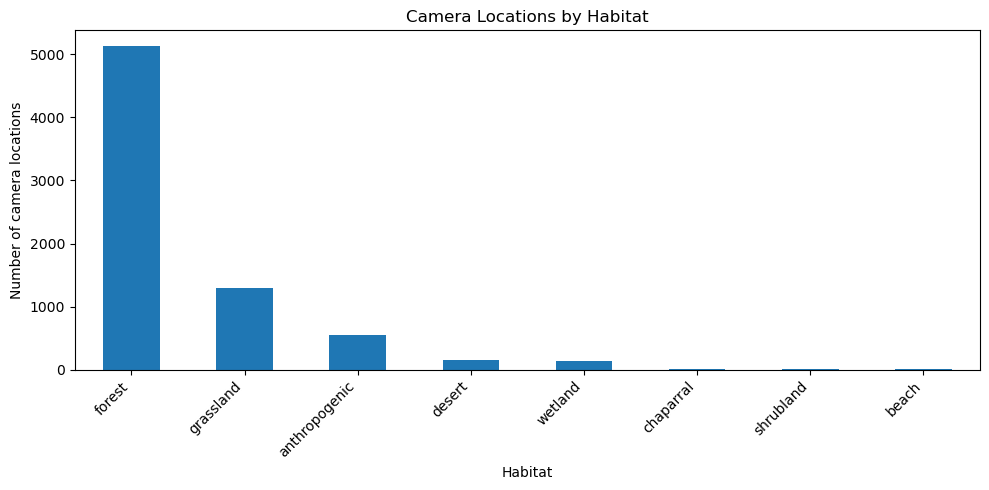

In [184]:
# Bar plot: number of camera locations by habitat
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

plot_df["Habitat"].value_counts().sort_values(ascending=False).plot(kind="bar")

plt.xlabel("Habitat")
plt.ylabel("Number of camera locations")
plt.title("Camera Locations by Habitat")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

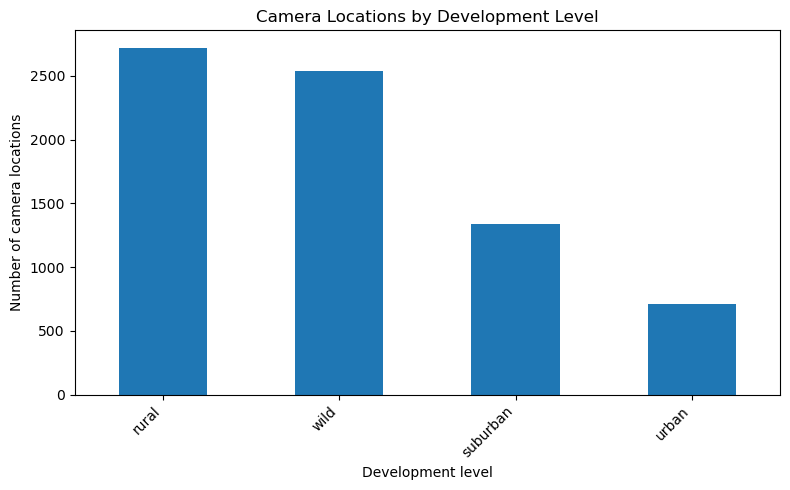

In [185]:
# Bar plot: number of camera locations by development level
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

plot_df["Development_Level"].value_counts().sort_values(ascending=False).plot(kind="bar")

plt.xlabel("Development level")
plt.ylabel("Number of camera locations")
plt.title("Camera Locations by Development Level")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

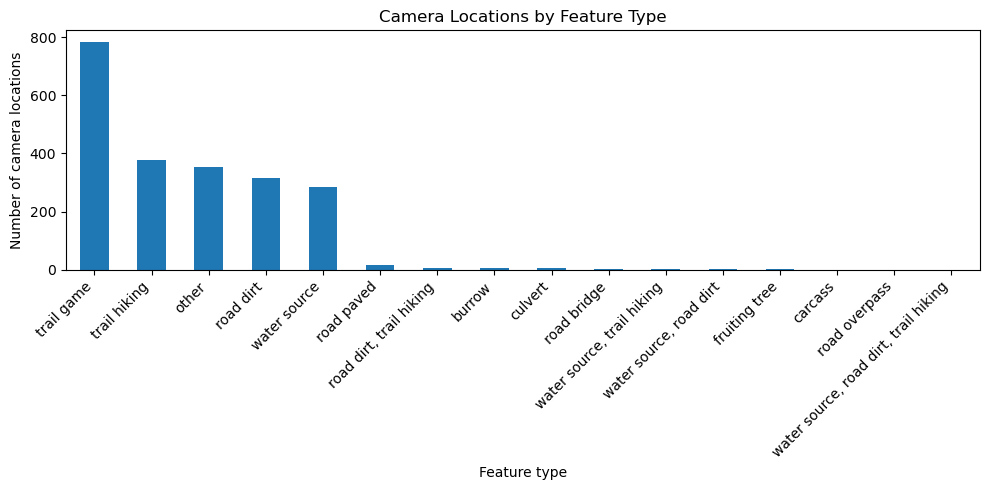

In [186]:
# Bar plot: number of camera locations by feature type
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

plot_df["Feature_Type"].value_counts().sort_values(ascending=False).plot(kind="bar")

plt.xlabel("Feature type")
plt.ylabel("Number of camera locations")
plt.title("Camera Locations by Feature Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

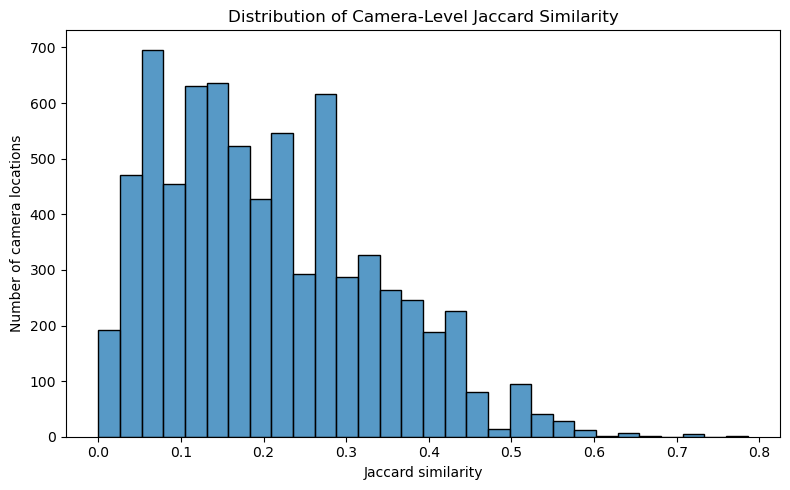

In [187]:
# Histogram: distribution of Jaccard similarity across cameras
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

sns.histplot(data=plot_df, x="jaccard_index", bins=30)

plt.xlabel("Jaccard similarity")
plt.ylabel("Number of camera locations")
plt.title("Distribution of Camera-Level Jaccard Similarity")
plt.tight_layout()
plt.show()

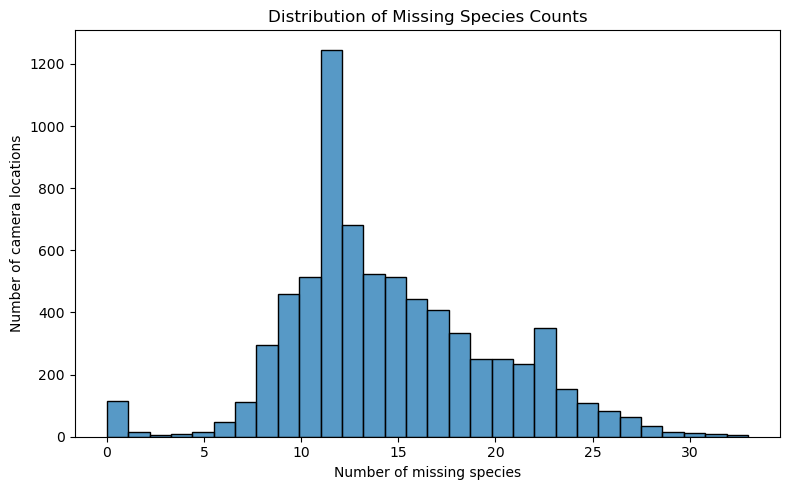

In [188]:
# Histogram: distribution of missing species counts
# Missing species = predicted by IUCN but not observed in SSUSA
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

sns.histplot(data=plot_df, x="missing_n", bins=30)

plt.xlabel("Number of missing species")
plt.ylabel("Number of camera locations")
plt.title("Distribution of Missing Species Counts")
plt.tight_layout()
plt.show()

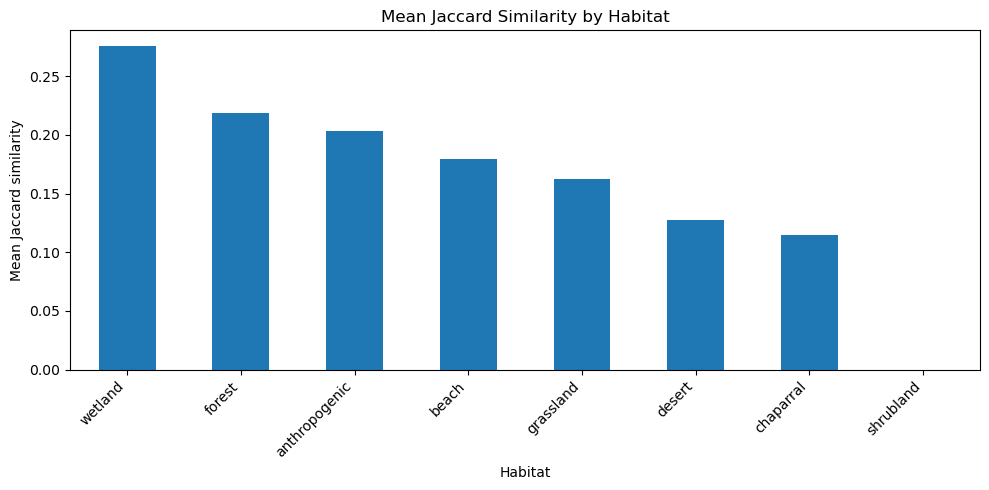

In [190]:
# Bar plot: mean Jaccard similarity by habitat
# ------------------------------------------------------------
mean_jaccard_habitat = (
    plot_df
    .groupby("Habitat")["jaccard_index"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

mean_jaccard_habitat.plot(kind="bar")

plt.xlabel("Habitat")
plt.ylabel("Mean Jaccard similarity")
plt.title("Mean Jaccard Similarity by Habitat")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

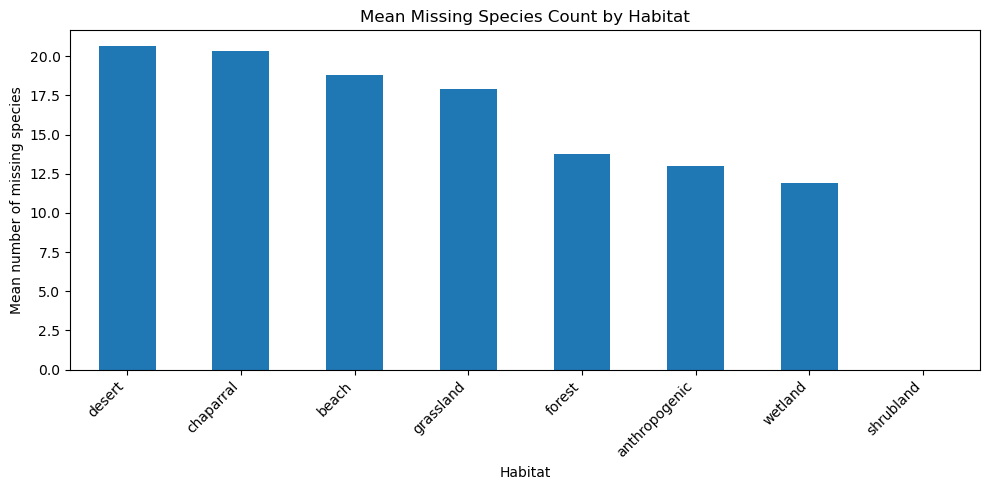

In [191]:
# Bar plot: mean missing species count by habitat
# ------------------------------------------------------------
mean_missing_habitat = (
    plot_df
    .groupby("Habitat")["missing_n"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

mean_missing_habitat.plot(kind="bar")

plt.xlabel("Habitat")
plt.ylabel("Mean number of missing species")
plt.title("Mean Missing Species Count by Habitat")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()